# Exploring United Kingdom Real Estate



We use the [real-estate in United Kingdom](https://www.kaggle.com/datasets/patriciaryserwelch/geonames-gb) to explore further the data and properties that could positively or negatively impact analysis or any model fitting for prediction purposes. 

# Upload libraries and data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/geonames-gb/geo_locations.csv
/kaggle/input/geonames-gb/summarised_property_price_data.csv


In [2]:
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i,y[i],y[i],fontsize=20,horizontalalignment='center')

In [3]:
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.rc

<function matplotlib.pyplot.rc(group, **kwargs)>

## Property prices overtime

The distribution of the summarised prices is shown and described in the [metadata description](https://www.kaggle.com/datasets/patriciaryserwelch/geonames-gb). We find out the data is reasonably clean and few cleaning pre-processing operations may be required, which enhances usability.

The size of the dataset has been reduced by 90% - the statistical summarisation has positively simplified the dataset. It may demand some computing resources to process. 



In [4]:
source = '/kaggle/input/geonames-gb/summarised_property_price_data.csv'
data = pd.read_csv(source)
data.shape

(807245, 16)

In [5]:
data.dtypes

Month              int64
Year               int64
Location          object
Property Type     object
Old/New           object
Tenure            object
Price:Count        int64
Price:Min          int64
Price:Mean       float64
Price:Std        float64
Price:Q1         float64
Price: Q2        float64
Price:Q3         float64
Price:Max          int64
Price:IQR        float64
Price:Range        int64
dtype: object

In [6]:
data.head()

,Month,Year,Location,Property Type,Old/New,Tenure,Price:Count,Price:Min,Price:Mean,Price:Std,Price:Q1,Price: Q2,Price:Q3,Price:Max,Price:IQR,Price:Range
0,1,2023,ABBOTS LANGLEY,D,N,F,2,674500,887250.000000,300873.935395,780875.0,887250.0,993625.0,1100000,212750.0,425500
1,1,2023,ABBOTS LANGLEY,S,N,F,1,438250,438250.000000,NaN,438250.0,438250.0,438250.0,438250,0.0,0
2,1,2023,ABBOTS LANGLEY,T,N,F,3,210000,344166.666667,116198.465280,310000.0,410000.0,411250.0,412500,101250.0,202500
3,1,2023,ABERAERON,D,N,F,4,171000,285250.000000,81385.400001,260250.0,305000.0,330000.0,360000,69750.0,189000
4,1,2023,ABERAERON,S,N,F,1,157500,157500.000000,NaN,157500.0,157500.0,157500.0,157500,0.0,0


Some standard deviation were set to NaN. There is only one observation. Therefore, we set it to -1, to prevent errors and miscomputations.

In [7]:
data.isnull().sum(axis = 0)

Month                 0
Year                  0
Location              0
Property Type         0
Old/New               0
Tenure                0
Price:Count           0
Price:Min             0
Price:Mean            0
Price:Std        183259
Price:Q1              0
Price: Q2             0
Price:Q3              0
Price:Max             0
Price:IQR             0
Price:Range           0
dtype: int64

In [8]:
data['Price:Std'] = data['Price:Std'].fillna(-1)
data.isnull().sum(axis = 0)

Month            0
Year             0
Location         0
Property Type    0
Old/New          0
Tenure           0
Price:Count      0
Price:Min        0
Price:Mean       0
Price:Std        0
Price:Q1         0
Price: Q2        0
Price:Q3         0
Price:Max        0
Price:IQR        0
Price:Range      0
dtype: int64

### Monthly and Yearly distribution
We discover the number of observations has increased between 2017 and 2024. It may not reflect the actual activity of properties sales or exchanged titles. 

The location may have been more refined between 2017 and 2024. Therefore, the monthly distribution appears to be negatively impacted. It appears no data for 2011 may have yet to be included within the dataset. It may cause some inaccuracies in predictions and analysis. The number of entries through time should be used for any data consumption.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


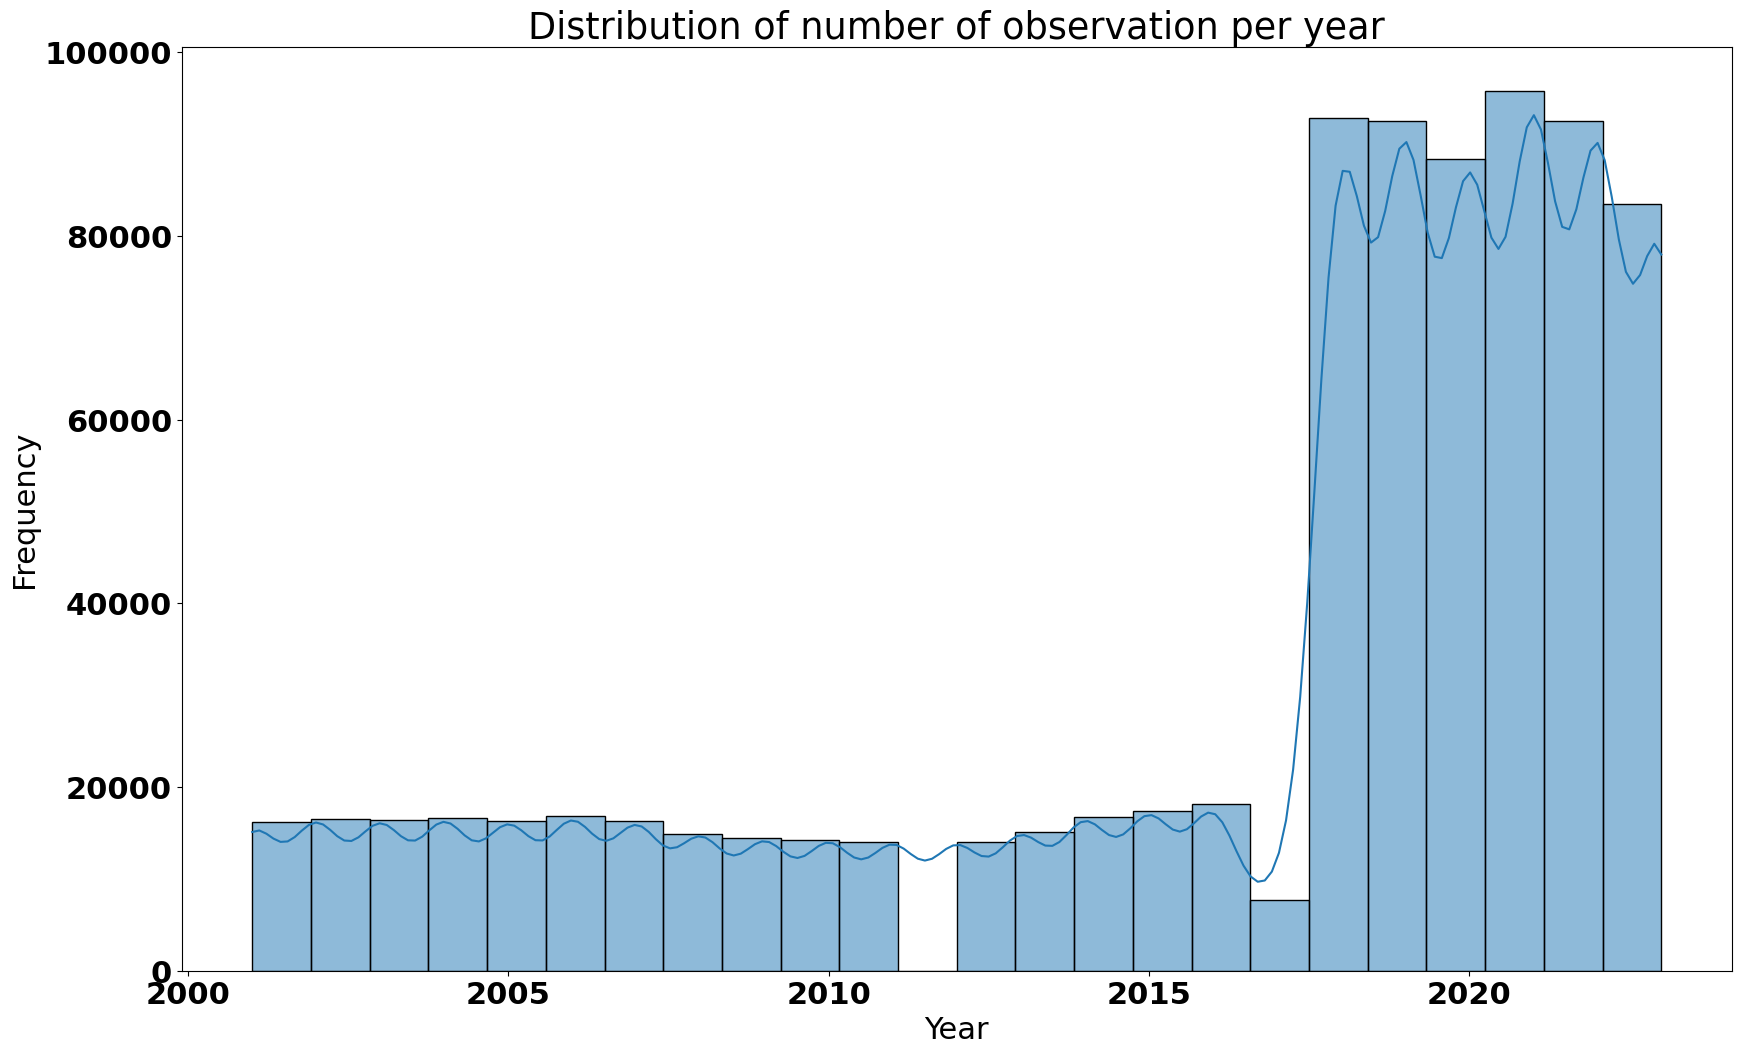

count    807245.000000
mean       2016.660658
std           6.304367
min        2001.000000
25%        2013.000000
50%        2019.000000
75%        2021.000000
max        2023.000000
Name: Year, dtype: float64

In [9]:
plt.figure(figsize=(20, 12))
sns.histplot(data=data, x='Year', bins=24, kde=True)
plt.title('Distribution of number of observation per year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()
data.Year.describe()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


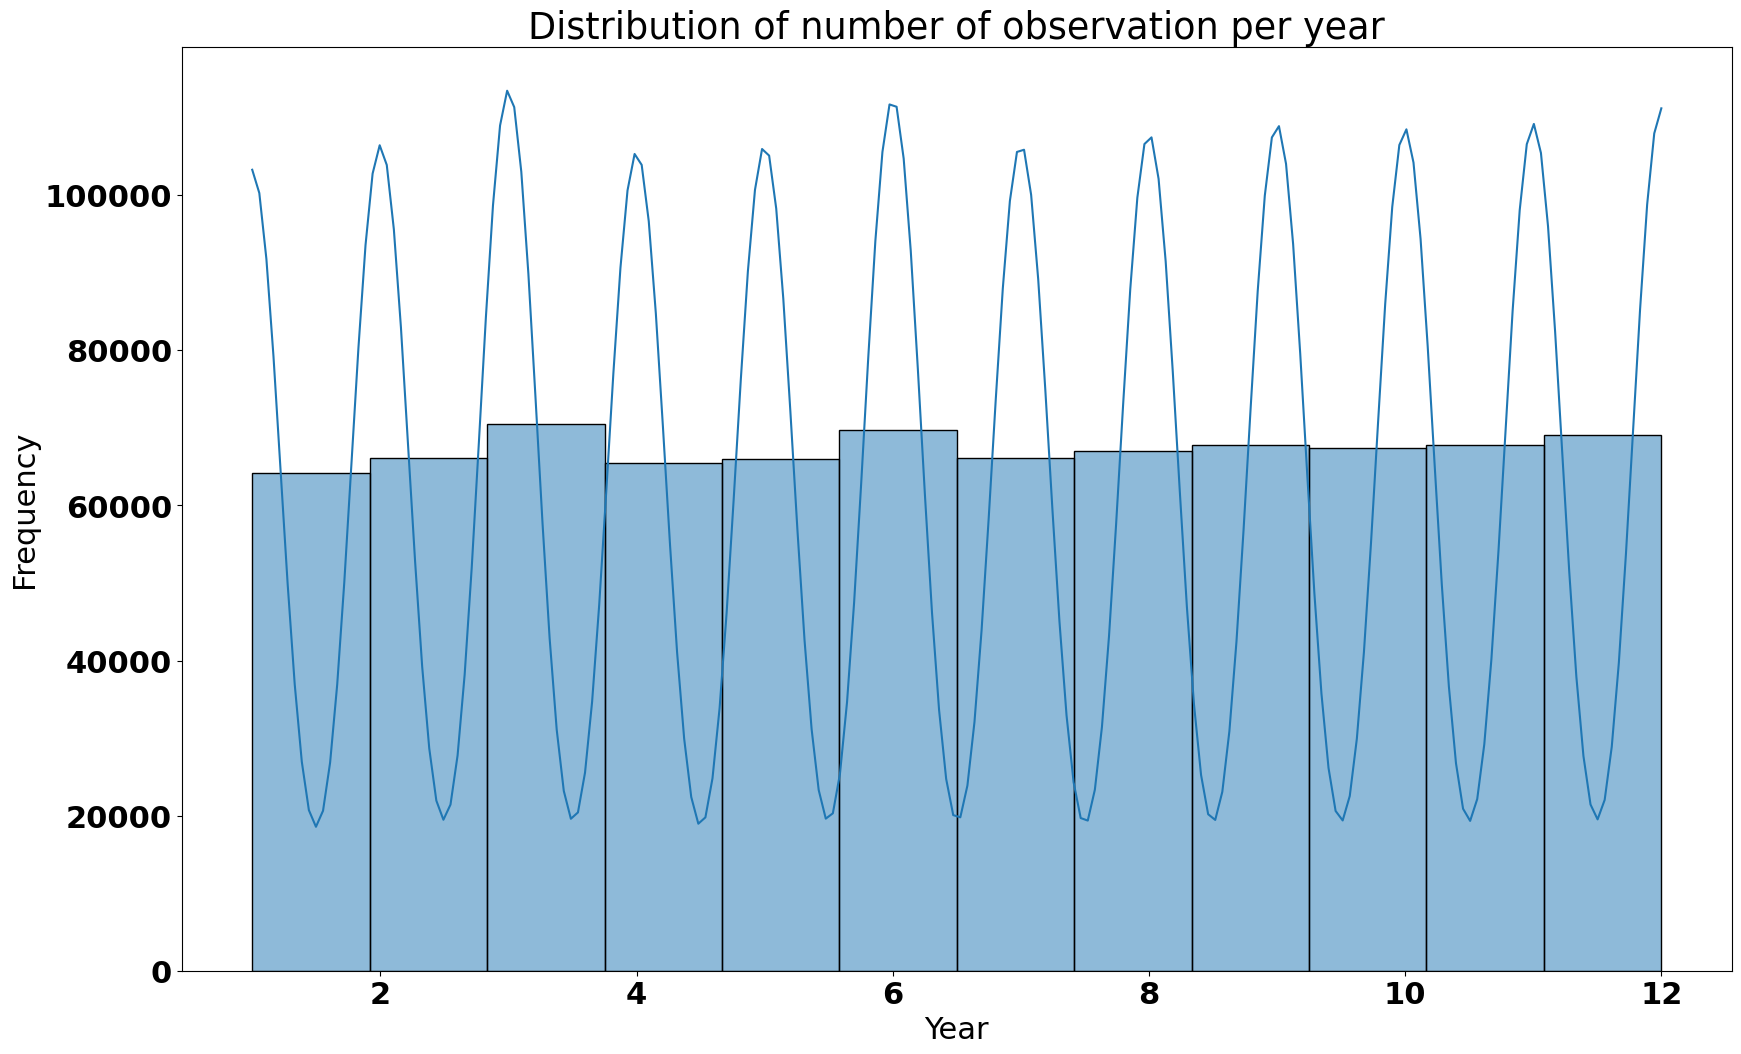

count    807245.000000
mean       2016.660658
std           6.304367
min        2001.000000
25%        2013.000000
50%        2019.000000
75%        2021.000000
max        2023.000000
Name: Year, dtype: float64

In [10]:
plt.figure(figsize=(20, 12))
sns.histplot(data=data, x='Month', bins=12, kde=True)
plt.title('Distribution of number of observation per year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()
data.Year.describe()

### Location

We discover and confirm the concept of location varies through the dataset. It appears more granularity in the locations exists after 2017.  However the majority of the locations are present in both time periods. Only St-Helens is not listed after 2018. 

In [11]:
len(data.Location.unique())

1152

In [12]:
rows = data.Year < 2018
col = 'Location'
before_2018 = data.loc[rows, col]
len(before_2018.unique())

135

In [13]:
rows = data.Year >= 2018
col = 'Location'
after_2018 = data.loc[rows, col]
len(after_2018.unique())

1151

In [14]:
before_2018 = set(before_2018)
after_2018  = set(after_2018)
before_2018.difference(after_2018)



{'ST. HELENS'}

We discover again that London and metropolitain cities are likely to have the most property exchanges. Smaller localities are likely to have a lot less. T


In [15]:
group = ['Location']
col   =  ['Price:Count']
grouped_by = data.groupby(group).sum()[col].reset_index()
grouped_by.sort_values('Price:Count')

,Location,Price:Count
522,KELSO,1
785,PORT DINORWIC,1
606,LLANSANFFRAID,2
423,GRETNA,7
403,GATWICK,7
...,...,...
556,LEEDS,254153
736,NOTTINGHAM,295664
112,BIRMINGHAM,330038
647,MANCHESTER,381448


In [16]:
locations = pd.read_csv("/kaggle/input/geonames-gb/geo_locations.csv")
locations.dtypes

Area          object
Name          object
Region        object
Latitude     float64
Longitude    float64
dtype: object

### Type of Property

The property type appears to be the same across the whole dataset.

In [17]:
len(data['Property Type'].unique())

5

In [18]:
rows = data.Year < 2018
col = 'Property Type'
before_2018 = data.loc[rows, col]
len(before_2018.unique())

5

In [19]:
rows = data.Year >= 2018
col = 'Property Type'
after_2018 = data.loc[rows, col]
len(after_2018.unique())

5

In [20]:
before_2018 = set(before_2018)
after_2018  = set(after_2018)
before_2018.difference(after_2018)



set()

We discover terraced houses (30%) are likely to be properties with the most exchanged titles, after semi-detached houses (27%) and flat. Others (3%) appears to be the least, with detached houses (20%) and flat (21%). 

This interpretations may suggest real-estates in the UK could be mainly composed of terraced houses, flats and semi-detached properties. 


In [21]:
group = ['Property Type']
col   =  ['Price:Count']
grouped_by = data.groupby(group).sum()[col].reset_index()
grouped_by.sort_values('Price:Count')

,Property Type,Price:Count
2,O,413560
0,D,2790506
1,F,2909812
3,S,3693681
4,T,4117586


In [22]:
grouped_by['Percentage'] = grouped_by['Price:Count'] / np.sum(grouped_by['Price:Count'])
grouped_by

,Property Type,Price:Count,Percentage
0,D,2790506,0.200393
1,F,2909812,0.208961
2,O,413560,0.029699
3,S,3693681,0.265253
4,T,4117586,0.295694


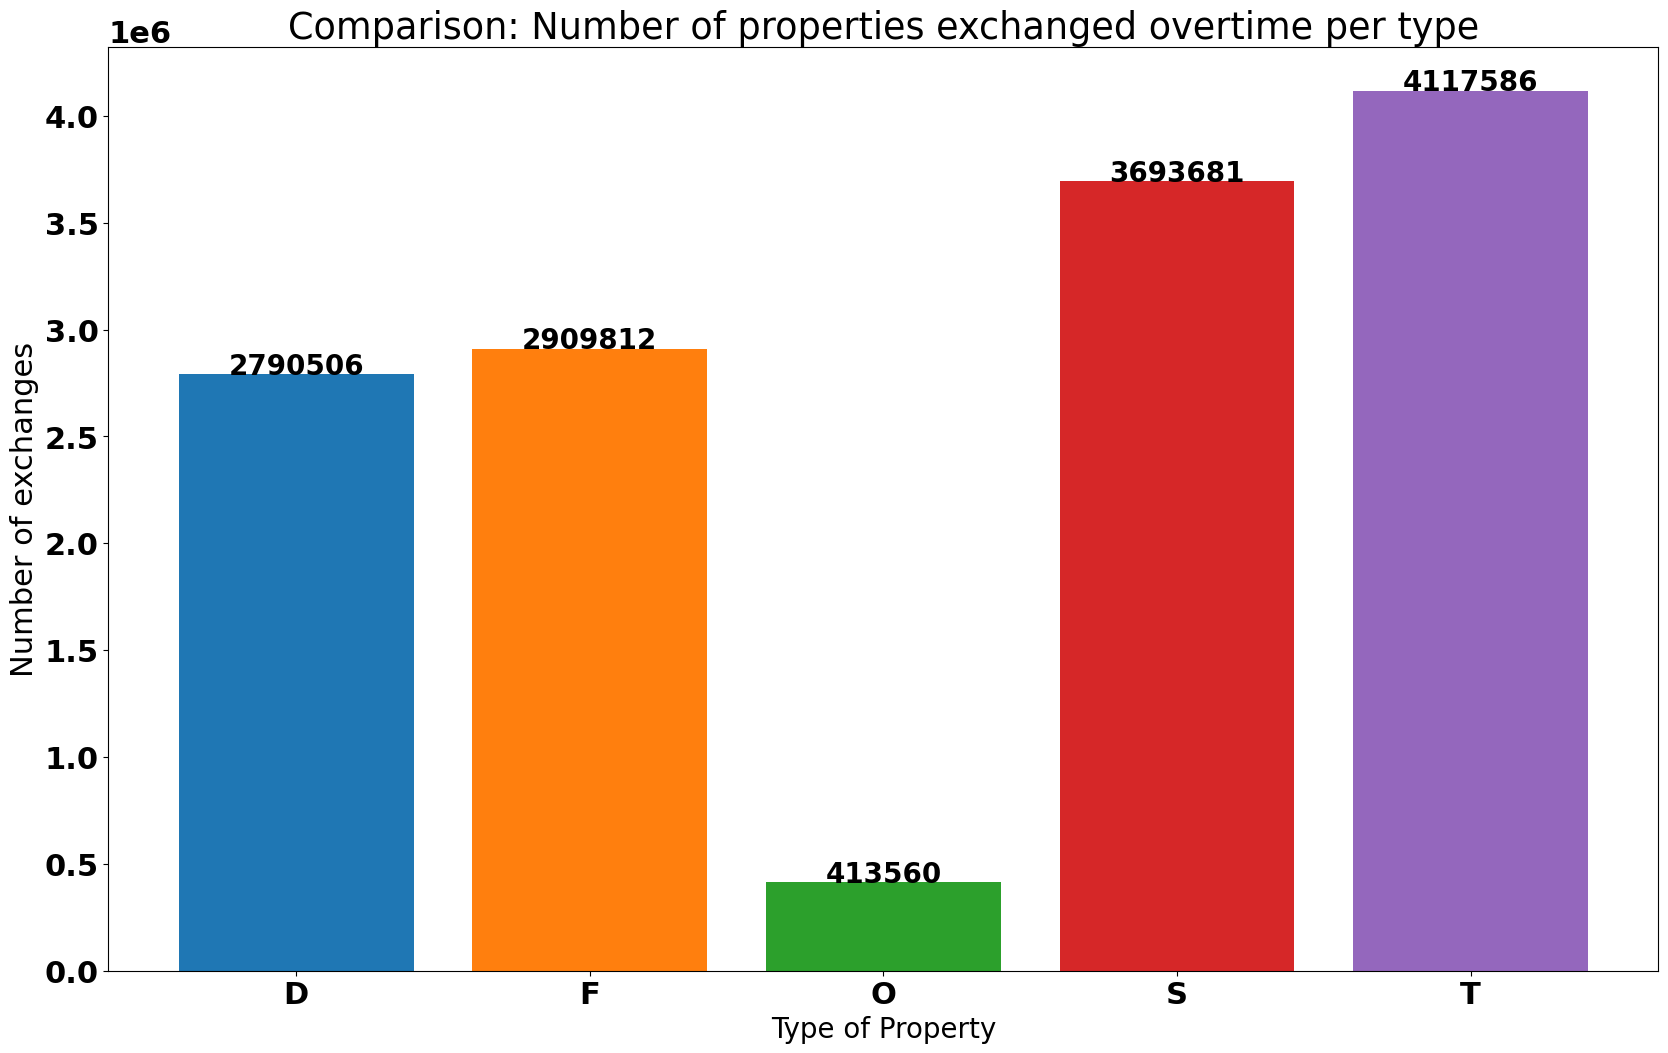

In [23]:
plt.figure(figsize=(20, 12))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
plt.bar(grouped_by['Property Type'],grouped_by['Price:Count'], color=colors )
addlabels(grouped_by['Property Type'],grouped_by['Price:Count'])
plt.title('Comparison: Number of properties exchanged overtime per type')
plt.xlabel('Type of Property',fontsize=20)
plt.ylabel('Number of exchanges')
plt.grid(False)
plt.show()

### Old/New

The old and new properties appears to be the same across the whole dataset.

In [24]:
len(data['Old/New'].unique())

2

In [25]:
rows = data.Year < 2018
col = 'Old/New'
before_2018 = data.loc[rows, col]
len(before_2018.unique())

2

In [26]:
rows = data.Year >= 2018
col = 'Old/New'
after_2018 = data.loc[rows, col]
len(after_2018.unique())

2

In [27]:
before_2018 = set(before_2018)
after_2018  = set(after_2018)
before_2018.difference(after_2018)



set()

We discover 10% of new  properties have been purchased.


In [ ]:
group = ['Old/New']
col   =  ['Price:Count']
grouped_by = data.groupby(group).sum()[col].reset_index()
grouped_by.sort_values('Price:Count')

In [29]:
grouped_by['Percentage'] = grouped_by['Price:Count'] / np.sum(grouped_by['Price:Count'])
grouped_by

,Old/New,Price:Count,Percentage
0,N,12400707,0.890526
1,Y,1524438,0.109474


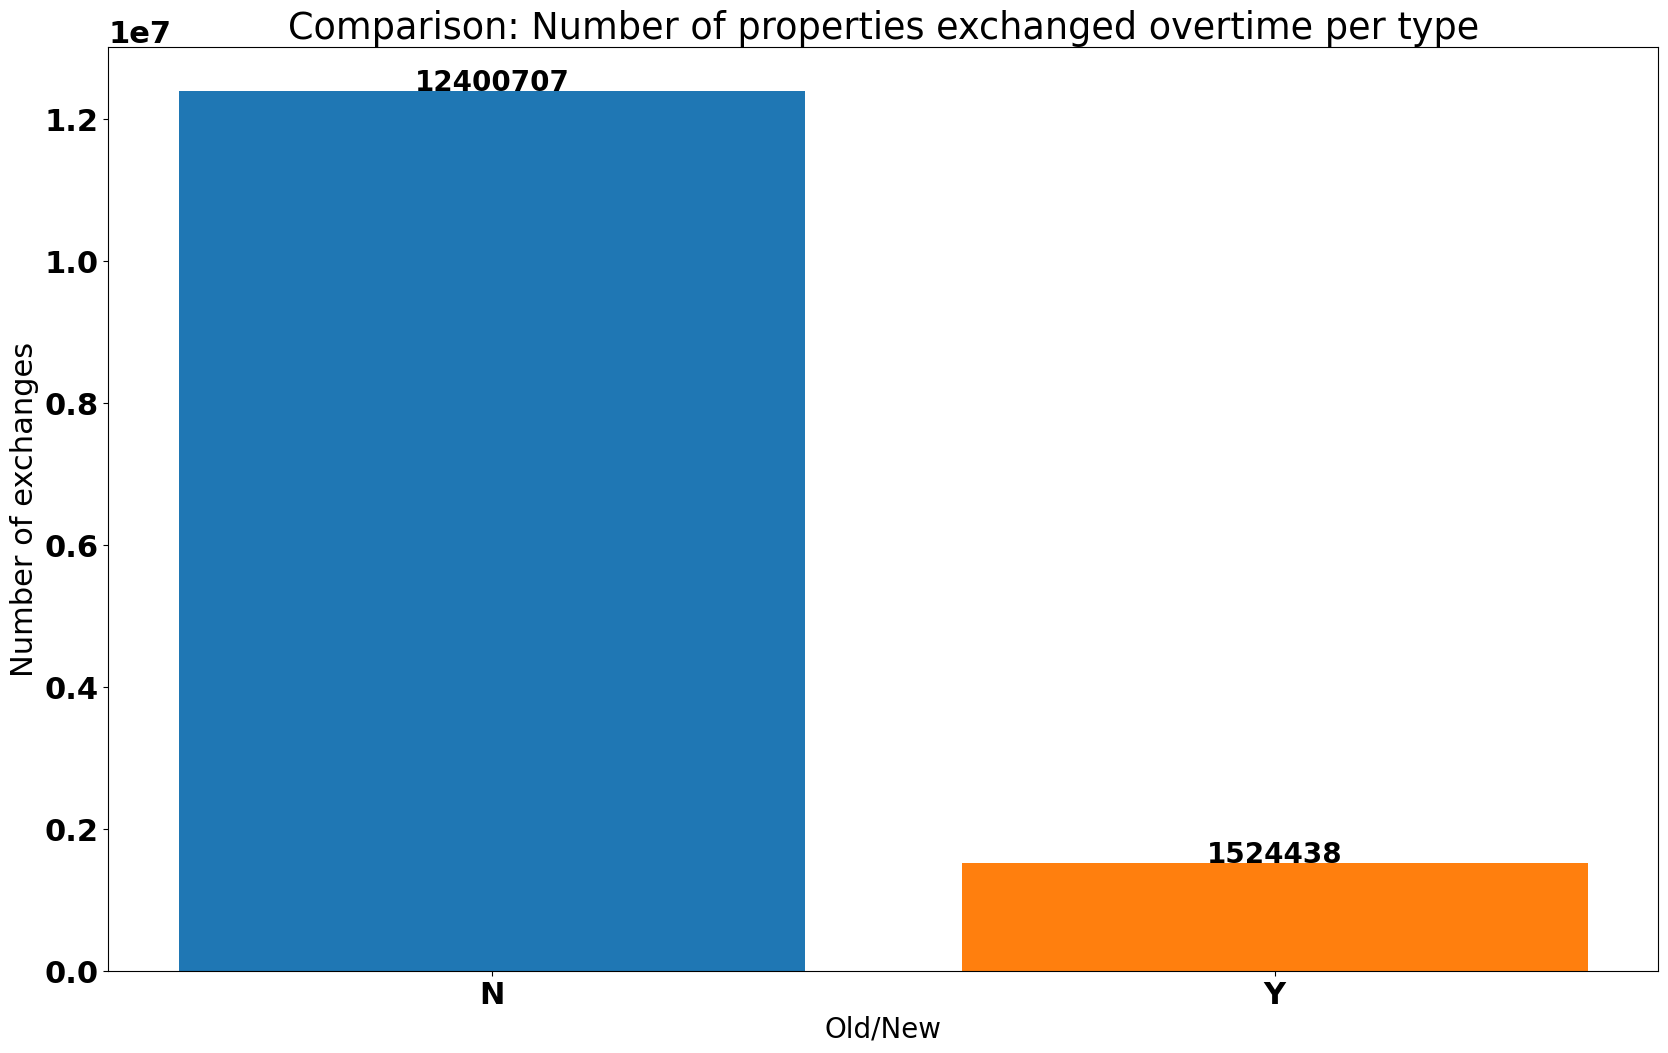

In [30]:
plt.figure(figsize=(20, 12))
colors = ['tab:blue', 'tab:orange']
plt.bar(grouped_by['Old/New'],grouped_by['Price:Count'], color=colors )
addlabels(grouped_by['Old/New'],grouped_by['Price:Count'])
plt.title('Comparison: Number of properties exchanged overtime per type')
plt.xlabel('Old/New',fontsize=20)
plt.ylabel('Number of exchanges')
plt.grid(False)
plt.show()

### Tenure 

The tenure of the property appears to improve through time. Some unspecified tenure was present in the data prior 2018, but none after 2018. This observation may suggest some analysis including the tenure may not be as accurate until 2018.

In [31]:
len(data['Tenure'].unique())

3

In [32]:
rows = data.Year < 2018
col = 'Tenure'
before_2018 = data.loc[rows, col]
len(before_2018.unique())

3

In [33]:
rows = data.Year >= 2018
col = 'Tenure'
after_2018 = data.loc[rows, col]
len(after_2018.unique())

2

In [34]:
before_2018 = set(before_2018)
after_2018  = set(after_2018)
before_2018.difference(after_2018)



{'U'}

We discover free-hold (73%) are likely to be properties with the most exchanged titles, after leasehold (27%). Less than 1% of tenure is unknow, which is very small.




In [35]:
group = ['Tenure']
col   =  ['Price:Count']
grouped_by = data.groupby(group).sum()[col].reset_index()
grouped_by.sort_values('Price:Count')

,Tenure,Price:Count
2,U,296
1,L,3818965
0,F,10105884


In [36]:
grouped_by['Percentage'] = grouped_by['Price:Count'] / np.sum(grouped_by['Price:Count'])
grouped_by

,Tenure,Price:Count,Percentage
0,F,10105884,0.725729
1,L,3818965,0.274250
2,U,296,0.000021


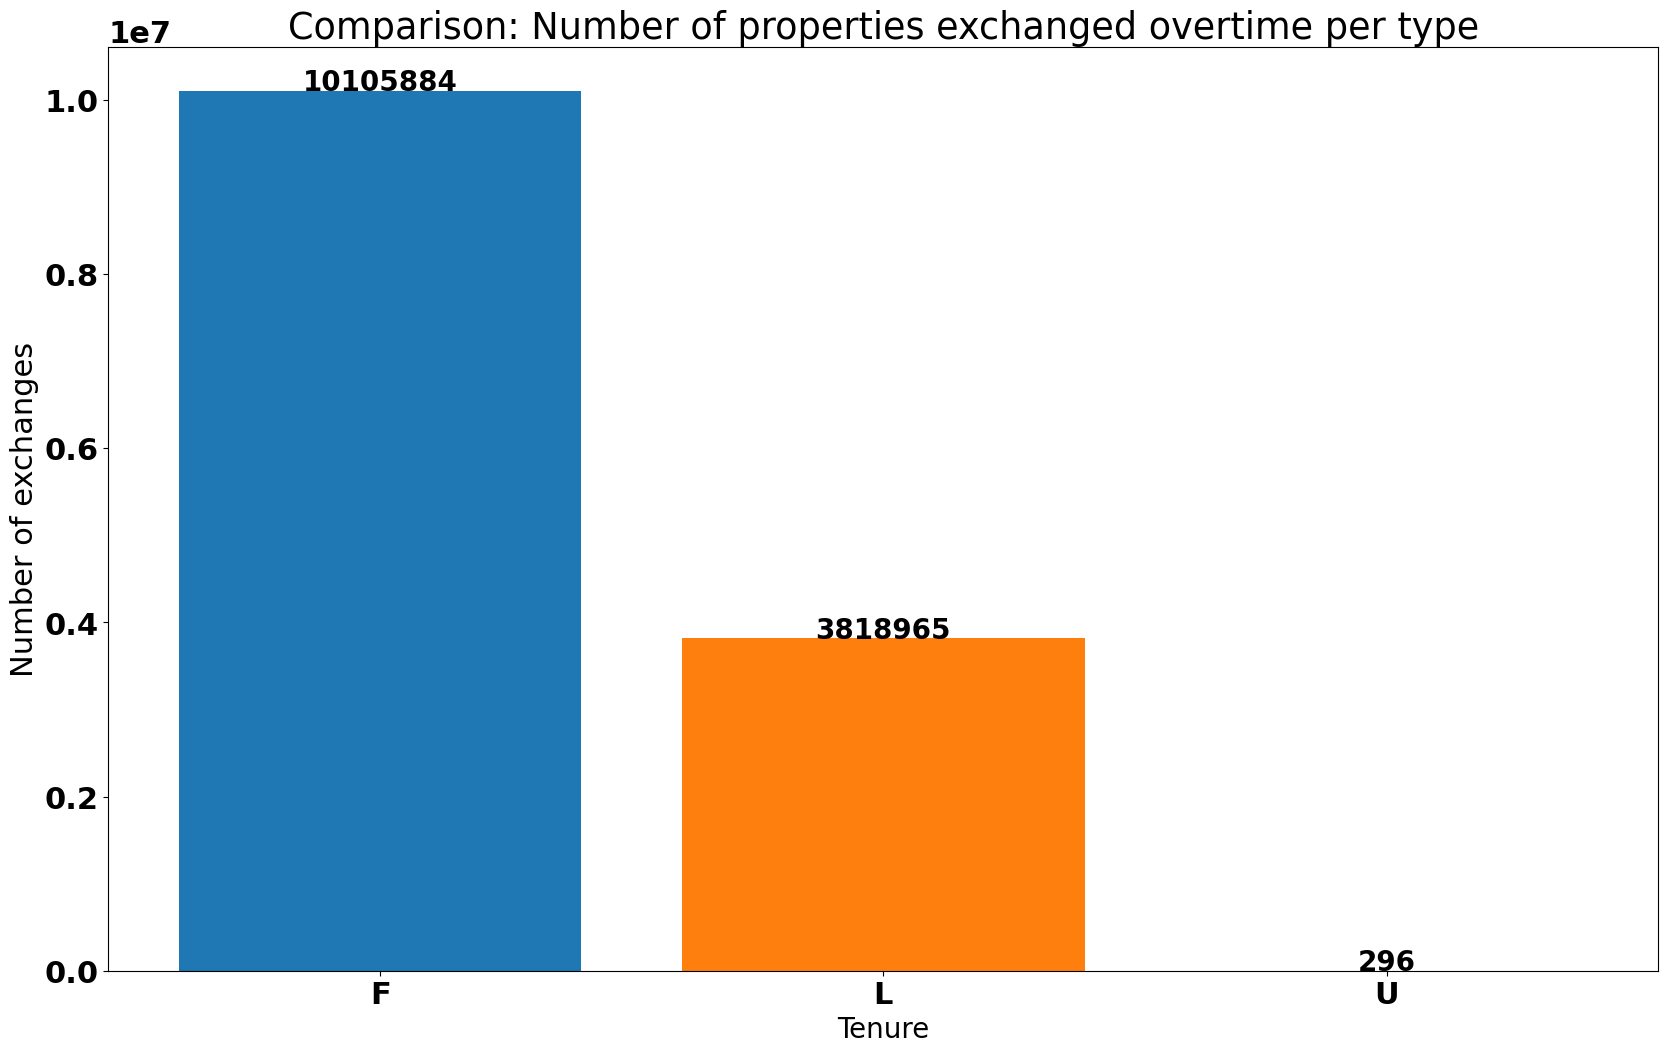

In [37]:
plt.figure(figsize=(20, 12))
colors = ['tab:blue', 'tab:orange', 'tab:green']
plt.bar(grouped_by['Tenure'],grouped_by['Price:Count'], color=colors )
addlabels(grouped_by['Tenure'],grouped_by['Price:Count'])
plt.title('Comparison: Number of properties exchanged overtime per type')
plt.xlabel('Tenure',fontsize=20)
plt.ylabel('Number of exchanges')
plt.grid(False)
plt.show()

# What can we explore using this data?

We have discovered the dataset is far from being perfect. For example, there is no monthly total value of properties titles exchange. It can be computed using the number of observation _Price:Count_ and _Price:Mean_.  

We should be able to overcome issues with the location using the geo_location datasets. Some better groupings and statistical analysis should be possible to create. The geographical data should help merging with known datasets that hold more population, economical and other socio-economical data. 

The number of titles exchanges per tenure, type of property, old/new,  month and year can be used to create some classes to help build some predictive models, using some random-forrest or other type of classifiers.  Some possible time series analysis may be possible too.